In [1]:
from sshtunnel import SSHTunnelForwarder

with SSHTunnelForwarder(
    ("13.239.79.237", 22),
    ssh_username="ubuntu",
    ssh_pkey="C:/Sagar/Futsal_ML/Futsal-ML-Analysis/Futsal_Match_Prediction/db_pass/FutsalozApp_ProdNew.pem",
    remote_bind_address=(
        "futsalozdb.ce8imxcnx4zv.ap-southeast-2.rds.amazonaws.com",
        3306
    )
) as tunnel:

    print("SSH Tunnel Connected")
    print("Local Port:", tunnel.local_bind_port)

c:\Sagar\Futsal_ML\Futsal-ML-Analysis\Futsal_Match_Prediction\.venv\Lib\site-packages\paramiko\pkey.py:82: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "cipher": algorithms.TripleDES,
c:\Sagar\Futsal_ML\Futsal-ML-Analysis\Futsal_Match_Prediction\.venv\Lib\site-packages\paramiko\transport.py:253: CryptographyDeprecationWarning: TripleDES has been moved to cryptography.hazmat.decrepit.ciphers.algorithms.TripleDES and will be removed from cryptography.hazmat.primitives.ciphers.algorithms in 48.0.0.
  "class": algorithms.TripleDES,


SSH Tunnel Connected
Local Port: 64625


In [2]:
import pandas as pd
from sqlalchemy import create_engine
from sshtunnel import SSHTunnelForwarder

SSH_HOST = "13.239.79.237"
SSH_PORT = 22
SSH_USER = "ubuntu"
SSH_KEY = "C:/Sagar/Futsal_ML/Futsal-ML-Analysis/Futsal_Match_Prediction/db_pass/FutsalozApp_ProdNew.pem"

MYSQL_HOST = "futsalozdb.ce8imxcnx4zv.ap-southeast-2.rds.amazonaws.com"
MYSQL_PORT = 3306
MYSQL_USER = "admin"
MYSQL_PASSWORD = "Dk2poYagiSAUu04wEBtH"
MYSQL_DATABASE = "futsaloz"

with SSHTunnelForwarder(
    (SSH_HOST, SSH_PORT),
    ssh_username=SSH_USER,
    ssh_pkey=SSH_KEY,
    remote_bind_address=(MYSQL_HOST, MYSQL_PORT)
) as tunnel:

    engine = create_engine(
        f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}"
        f"@127.0.0.1:{tunnel.local_bind_port}/{MYSQL_DATABASE}"
    )

#     query = """
#     SELECT lmsc.*,
#     u.first_name,
#     u.last_name,
#     u.date_of_birth
# FROM futsaloz.live_match_score_cards lmsc
# LEFT JOIN futsaloz.users u
#     ON lmsc.user_id = u.user_id;
#     """

    query="""
    SELECT
    lmsc.*,
    u.first_name,
    u.last_name,
    u.date_of_birth
FROM futsaloz.live_match_score_cards lmsc
LEFT JOIN futsaloz.users u
    ON lmsc.user_id = u.user_id
WHERE lmsc.comp_id IN (
    1028, 948, 878, 725, 627,
    527, 430, 312, 238, 130
)
AND lmsc.type IN (
    'SCORE',
    'FOULS',
    'YELLOWCARD',
    'REDCARD'
)
AND lmsc.user_id <> 3;"""

    player_raw = pd.read_sql(query, engine)
    
player_raw

,id,match_id,comp_id,team_id,user_id,assist_player_id,type,is_self_goal,time,timer_type,half,match_time,is_goal,is_reset,created_on,updated_on,first_name,last_name,date_of_birth
0,44170,41517,130,21,435,NaN,SCORE,0,18:39,PLAY,1,18:39,1,0,2021-04-23 14:25:49,2021-04-23 14:25:49,Daniel,Chaabani,2020-01-21
1,44171,41517,130,19,722,NaN,SCORE,0,14:46,PLAY,1,14:46,1,0,2021-04-23 14:29:41,2021-04-23 14:29:41,Edison,Ponari,1996-01-20
2,44172,41517,130,21,514,NaN,SCORE,0,06:37,PLAY,1,06:37,1,0,2021-04-23 14:37:50,2021-04-23 14:37:50,Henrique,Pimenta,1992-08-24
3,44180,41517,130,21,514,NaN,SCORE,0,01:50,PLAY,1,01:50,1,0,2021-04-23 14:44:19,2021-04-23 14:44:19,Henrique,Pimenta,1992-08-24
4,44181,41517,130,19,700,NaN,FOULS,0,00:35,PLAY,1,00:35,0,0,2021-04-23 14:45:34,2021-04-23 14:45:34,Camilo,Marin,1994-07-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14419,1560622,250502,1028,18,526,0.0,FOULS,0,02:32,PLAY,2,02:32,0,0,2026-06-07 16:00:06,2026-06-07 16:00:06,Kevin Robert,Messias dos Santos,1995-06-21
14420,1560643,250502,1028,331,733,0.0,FOULS,0,01:20,PLAY,2,01:20,0,0,2026-06-07 16:03:24,2026-06-07 16:03:24,Hamza,Soueid,2003-03-16
14421,1560654,250502,1028,18,33452,0.0,FOULS,0,00:33,PLAY,2,00:33,0,0,2026-06-07 16:06:04,2026-06-07 16:06:04,Grant,Lynch,1993-08-04
14422,1560655,250502,1028,18,33452,0.0,YELLOWCARD,0,00:33,PLAY,2,00:33,0,0,2026-06-07 16:06:07,2026-06-07 16:06:07,Grant,Lynch,1993-08-04


In [3]:
import pandas as pd
from sqlalchemy import create_engine
from sshtunnel import SSHTunnelForwarder

SSH_HOST = "13.239.79.237"
SSH_PORT = 22
SSH_USER = "ubuntu"
SSH_KEY = "C:/Sagar/Futsal_ML/Futsal-ML-Analysis/Futsal_Match_Prediction/db_pass/FutsalozApp_ProdNew.pem"

MYSQL_HOST = "futsalozdb.ce8imxcnx4zv.ap-southeast-2.rds.amazonaws.com"
MYSQL_PORT = 3306
MYSQL_USER = "admin"
MYSQL_PASSWORD = "Dk2poYagiSAUu04wEBtH"
MYSQL_DATABASE = "futsaloz"

with SSHTunnelForwarder(
    (SSH_HOST, SSH_PORT),
    ssh_username=SSH_USER,
    ssh_pkey=SSH_KEY,
    remote_bind_address=(MYSQL_HOST, MYSQL_PORT)
) as tunnel:

    engine = create_engine(
        f"mysql+pymysql://{MYSQL_USER}:{MYSQL_PASSWORD}"
        f"@127.0.0.1:{tunnel.local_bind_port}/{MYSQL_DATABASE}"
    )

    query = """
SELECT
    m.*,
    ht.name AS homeTeamName,
    at.name AS awayTeamName,
    c.name AS competitionName,
    s.name AS seasonName
FROM futsaloz.cmp_matches m
LEFT JOIN futsaloz.teams ht
    ON m.homeTeamId = ht.id
LEFT JOIN futsaloz.teams at
    ON m.awayTeamId = at.id
LEFT JOIN futsaloz.competition c
    ON m.cmp_id = c.id
LEFT JOIN futsaloz.season s
    ON c.season_id = s.id
WHERE m.cmp_id IN (
    1028, 948, 878, 725, 627,
    527, 430, 312, 238, 130
);
"""
    matches_raw = pd.read_sql(query, engine)
    
matches_raw

,id,cmp_id,homeTeam,awayTeam,homeTeamId,awayTeamId,startTime,endTime,startDate,startingTime,...,is_bye,note,is_forfeited,is_cancel,homeTeamKits,awayTeamKits,homeTeamName,awayTeamName,competitionName,seasonName
0,41517,130,T4,T9,19,21,2021-04-23 18:45:00,2021-04-23 19:45:00,2021-04-23,18:45:00,...,false,NaN,false,no,0,0,Altona Knights FC,Campbellfield FC,2021 Series Futsal Victoria Men,2021
1,41518,130,T2,T7,325,18,2021-04-23 19:45:00,2021-04-23 20:45:00,2021-04-23,19:45:00,...,false,NaN,false,no,0,0,Roxburgh Park Gorillas,Moreland Blues FC,2021 Series Futsal Victoria Men,2021
2,41519,130,T5,T10,16,23,2021-04-23 20:45:00,2021-04-23 21:45:00,2021-04-23,20:45:00,...,false,NaN,false,no,0,0,Pascoe Vale FC,Yarra Allstars FC,2021 Series Futsal Victoria Men,2021
3,41520,130,T3,T8,20,22,2021-04-23 21:45:00,2021-04-23 22:45:00,2021-04-23,21:45:00,...,false,NaN,false,no,0,0,Western United FC,FC Carlton Heart,2021 Series Futsal Victoria Men,2021
4,41521,130,T1,T6,17,207,2021-04-23 22:45:00,2021-04-23 23:45:00,2021-04-23,22:45:00,...,false,NaN,false,no,0,0,Fitzroy FC,Vic Friendship FC,2021 Series Futsal Victoria Men,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,250563,1028,T5,T4,331,18,2026-11-29 19:50:00,2026-11-29 20:45:00,2026-11-29,19:50:00,...,false,NaN,false,no,52,50,Hume FC,Moreland Blues FC,2026 SERIES FUTSAL Premiership Men,2026
842,250564,1028,T2,Bye,22,0,2026-12-06 04:00:00,2026-12-06 04:55:00,2026-12-06,04:00:00,...,true,NaN,false,no,0,0,FC Carlton Heart,NaN,2026 SERIES FUTSAL Premiership Men,2026
843,250565,1028,T3,T4,16,329,2026-12-06 16:50:00,2026-12-06 17:45:00,2026-12-06,16:50:00,...,false,NaN,false,no,118,28,Pascoe Vale FC,Melbourne AKU FC,2026 SERIES FUTSAL Premiership Men,2026
844,250566,1028,T1,T6,17,18,2026-12-06 18:20:00,2026-12-06 19:15:00,2026-12-06,18:20:00,...,false,NaN,false,no,38,51,Fitzroy FC,Moreland Blues FC,2026 SERIES FUTSAL Premiership Men,2026


In [4]:
matches = matches_raw.copy()
matches

,id,cmp_id,homeTeam,awayTeam,homeTeamId,awayTeamId,startTime,endTime,startDate,startingTime,...,is_bye,note,is_forfeited,is_cancel,homeTeamKits,awayTeamKits,homeTeamName,awayTeamName,competitionName,seasonName
0,41517,130,T4,T9,19,21,2021-04-23 18:45:00,2021-04-23 19:45:00,2021-04-23,18:45:00,...,false,NaN,false,no,0,0,Altona Knights FC,Campbellfield FC,2021 Series Futsal Victoria Men,2021
1,41518,130,T2,T7,325,18,2021-04-23 19:45:00,2021-04-23 20:45:00,2021-04-23,19:45:00,...,false,NaN,false,no,0,0,Roxburgh Park Gorillas,Moreland Blues FC,2021 Series Futsal Victoria Men,2021
2,41519,130,T5,T10,16,23,2021-04-23 20:45:00,2021-04-23 21:45:00,2021-04-23,20:45:00,...,false,NaN,false,no,0,0,Pascoe Vale FC,Yarra Allstars FC,2021 Series Futsal Victoria Men,2021
3,41520,130,T3,T8,20,22,2021-04-23 21:45:00,2021-04-23 22:45:00,2021-04-23,21:45:00,...,false,NaN,false,no,0,0,Western United FC,FC Carlton Heart,2021 Series Futsal Victoria Men,2021
4,41521,130,T1,T6,17,207,2021-04-23 22:45:00,2021-04-23 23:45:00,2021-04-23,22:45:00,...,false,NaN,false,no,0,0,Fitzroy FC,Vic Friendship FC,2021 Series Futsal Victoria Men,2021
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,250563,1028,T5,T4,331,18,2026-11-29 19:50:00,2026-11-29 20:45:00,2026-11-29,19:50:00,...,false,NaN,false,no,52,50,Hume FC,Moreland Blues FC,2026 SERIES FUTSAL Premiership Men,2026
842,250564,1028,T2,Bye,22,0,2026-12-06 04:00:00,2026-12-06 04:55:00,2026-12-06,04:00:00,...,true,NaN,false,no,0,0,FC Carlton Heart,NaN,2026 SERIES FUTSAL Premiership Men,2026
843,250565,1028,T3,T4,16,329,2026-12-06 16:50:00,2026-12-06 17:45:00,2026-12-06,16:50:00,...,false,NaN,false,no,118,28,Pascoe Vale FC,Melbourne AKU FC,2026 SERIES FUTSAL Premiership Men,2026
844,250566,1028,T1,T6,17,18,2026-12-06 18:20:00,2026-12-06 19:15:00,2026-12-06,18:20:00,...,false,NaN,false,no,38,51,Fitzroy FC,Moreland Blues FC,2026 SERIES FUTSAL Premiership Men,2026


In [5]:
players = player_raw.copy()
players

,id,match_id,comp_id,team_id,user_id,assist_player_id,type,is_self_goal,time,timer_type,half,match_time,is_goal,is_reset,created_on,updated_on,first_name,last_name,date_of_birth
0,44170,41517,130,21,435,NaN,SCORE,0,18:39,PLAY,1,18:39,1,0,2021-04-23 14:25:49,2021-04-23 14:25:49,Daniel,Chaabani,2020-01-21
1,44171,41517,130,19,722,NaN,SCORE,0,14:46,PLAY,1,14:46,1,0,2021-04-23 14:29:41,2021-04-23 14:29:41,Edison,Ponari,1996-01-20
2,44172,41517,130,21,514,NaN,SCORE,0,06:37,PLAY,1,06:37,1,0,2021-04-23 14:37:50,2021-04-23 14:37:50,Henrique,Pimenta,1992-08-24
3,44180,41517,130,21,514,NaN,SCORE,0,01:50,PLAY,1,01:50,1,0,2021-04-23 14:44:19,2021-04-23 14:44:19,Henrique,Pimenta,1992-08-24
4,44181,41517,130,19,700,NaN,FOULS,0,00:35,PLAY,1,00:35,0,0,2021-04-23 14:45:34,2021-04-23 14:45:34,Camilo,Marin,1994-07-11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14419,1560622,250502,1028,18,526,0.0,FOULS,0,02:32,PLAY,2,02:32,0,0,2026-06-07 16:00:06,2026-06-07 16:00:06,Kevin Robert,Messias dos Santos,1995-06-21
14420,1560643,250502,1028,331,733,0.0,FOULS,0,01:20,PLAY,2,01:20,0,0,2026-06-07 16:03:24,2026-06-07 16:03:24,Hamza,Soueid,2003-03-16
14421,1560654,250502,1028,18,33452,0.0,FOULS,0,00:33,PLAY,2,00:33,0,0,2026-06-07 16:06:04,2026-06-07 16:06:04,Grant,Lynch,1993-08-04
14422,1560655,250502,1028,18,33452,0.0,YELLOWCARD,0,00:33,PLAY,2,00:33,0,0,2026-06-07 16:06:07,2026-06-07 16:06:07,Grant,Lynch,1993-08-04


In [6]:
print("\nCOLUMNS")
print(players.columns)

print("\nDATA TYPES")
print(players.dtypes)

print("\nHEAD")
display(players.head())


COLUMNS
Index(['id', 'match_id', 'comp_id', 'team_id', 'user_id', 'assist_player_id',
       'type', 'is_self_goal', 'time', 'timer_type', 'half', 'match_time',
       'is_goal', 'is_reset', 'created_on', 'updated_on', 'first_name',
       'last_name', 'date_of_birth'],
      dtype='str')

DATA TYPES
id                           int64
match_id                     int64
comp_id                      int64
team_id                      int64
user_id                      int64
assist_player_id           float64
type                           str
is_self_goal                 int64
time                           str
timer_type                     str
half                         int64
match_time                     str
is_goal                        str
is_reset                       str
created_on          datetime64[us]
updated_on          datetime64[us]
first_name                     str
last_name                      str
date_of_birth                  str
dtype: object

HEAD


,id,match_id,comp_id,team_id,user_id,assist_player_id,type,is_self_goal,time,timer_type,half,match_time,is_goal,is_reset,created_on,updated_on,first_name,last_name,date_of_birth
0,44170,41517,130,21,435,NaN,SCORE,0,18:39,PLAY,1,18:39,1,0,2021-04-23 14:25:49,2021-04-23 14:25:49,Daniel,Chaabani,2020-01-21
1,44171,41517,130,19,722,NaN,SCORE,0,14:46,PLAY,1,14:46,1,0,2021-04-23 14:29:41,2021-04-23 14:29:41,Edison,Ponari,1996-01-20
2,44172,41517,130,21,514,NaN,SCORE,0,06:37,PLAY,1,06:37,1,0,2021-04-23 14:37:50,2021-04-23 14:37:50,Henrique,Pimenta,1992-08-24
3,44180,41517,130,21,514,NaN,SCORE,0,01:50,PLAY,1,01:50,1,0,2021-04-23 14:44:19,2021-04-23 14:44:19,Henrique,Pimenta,1992-08-24
4,44181,41517,130,19,700,NaN,FOULS,0,00:35,PLAY,1,00:35,0,0,2021-04-23 14:45:34,2021-04-23 14:45:34,Camilo,Marin,1994-07-11


In [7]:
# =============================================================================
# MISSING VALUES
# =============================================================================

missing = (

    players.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_pct = (

    missing / len(players)
) * 100

missing_df = pd.DataFrame({

    'missing_count': missing,
    'missing_pct': missing_pct

})

print("\nMISSING VALUES")
display(missing_df)


MISSING VALUES


,missing_count,missing_pct
assist_player_id,13220,91.652801
time,1334,9.248475
id,0,0.000000
comp_id,0,0.000000
match_id,0,0.000000
user_id,0,0.000000
team_id,0,0.000000
type,0,0.000000
is_self_goal,0,0.000000
timer_type,0,0.000000


In [8]:
# =============================================================================
# DUPLICATES
# =============================================================================

duplicates = players.duplicated().sum()

print("\nDUPLICATES:", duplicates)


DUPLICATES: 0



EVENT TYPE COUNTS


type
FOULS         6977
SCORE         5897
YELLOWCARD    1411
REDCARD        139
Name: count, dtype: int64

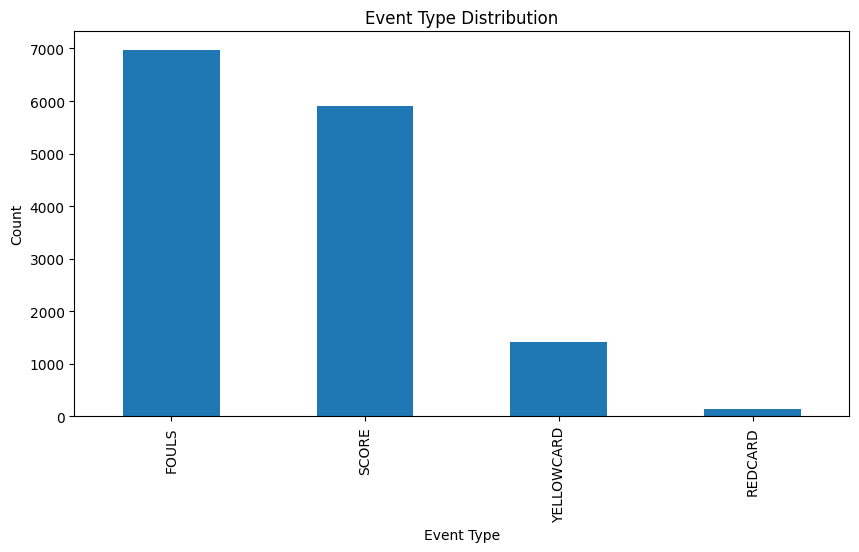

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =============================================================================
# EVENT TYPE DISTRIBUTION
# =============================================================================

print("\nEVENT TYPE COUNTS")

event_counts = (
    players['type']
    .astype(str)
    .str.upper()
    .value_counts()
)

display(event_counts)

# PLOT
plt.figure(figsize=(10,5))

event_counts.plot(kind='bar')

plt.title("Event Type Distribution")

plt.xlabel("Event Type")
plt.ylabel("Count")

plt.show()

In [10]:
# =============================================================================
# UNIQUE PLAYERS
# =============================================================================

unique_players = players['user_id'].nunique()

print("\nUNIQUE PLAYERS:", unique_players)


UNIQUE PLAYERS: 538


In [11]:
# =============================================================================
# UNIQUE MATCHES
# =============================================================================

unique_matches = players['match_id'].nunique()

print("UNIQUE MATCHES:", unique_matches)

UNIQUE MATCHES: 680


In [12]:
# =============================================================================
# EVENTS PER MATCH
# =============================================================================

events_per_match = (

    players.groupby('match_id')
    .size()
)

print("\nEVENTS PER MATCH")

display(events_per_match.describe())


EVENTS PER MATCH


count    680.000000
mean      21.211765
std        6.488634
min        3.000000
25%       17.000000
50%       21.000000
75%       25.000000
max       43.000000
dtype: float64

In [13]:
# =============================================================================
# EVENTS PER PLAYER
# =============================================================================

events_per_player = (

    players.groupby('user_id')
    .size()
)

print("\nEVENTS PER PLAYER")

display(events_per_player.describe())


EVENTS PER PLAYER


count    538.000000
mean      26.810409
std       48.499509
min        1.000000
25%        3.000000
50%        9.000000
75%       30.750000
max      385.000000
dtype: float64

In [14]:
# =============================================================================
# GOAL ANALYSIS
# =============================================================================

players['type'] = (
    players['type']
    .astype(str)
    .str.upper()
)

players['goal'] = np.where(
    players['type'] == 'SCORE',
    1,
    0
)

goal_events = players['goal'].sum()

print("\nTOTAL GOALS:", goal_events)


TOTAL GOALS: 5897


In [15]:
# =============================================================================
# TOP SCORERS
# =============================================================================

top_scorers = (

    players.groupby(
        ['user_id', 'first_name', 'last_name']
    )['goal']

    .sum()

    .sort_values(ascending=False)

    .head(20)
)

print("\nTOP SCORERS")

display(top_scorers)


TOP SCORERS


user_id  first_name     last_name          
429      Cosimo         Russo                  283
401      Scott          Rogan                  195
384      Elias          Parthimos              186
514      Henrique       Pimenta                161
1724     Josh           Allen                  137
458      Ubeyde         Cicek                  136
715      Adam           Cooper                 136
1714     Behrad         Behzadpour             124
617      Jose           Silva                  119
1190     Harry          Robotis                117
473      Andre          Caro Salve             107
526      Kevin Robert   Messias dos Santos     100
5106     sinan          gluhak                  79
453      Chaaban        Rajab                   74
1722     Corey          Sewell                  74
555      Kevin          Lam                     71
23897    Robson         Aparecido de Souza      65
441      Muhammed       Temel                   62
528      Michael        Nguyen        

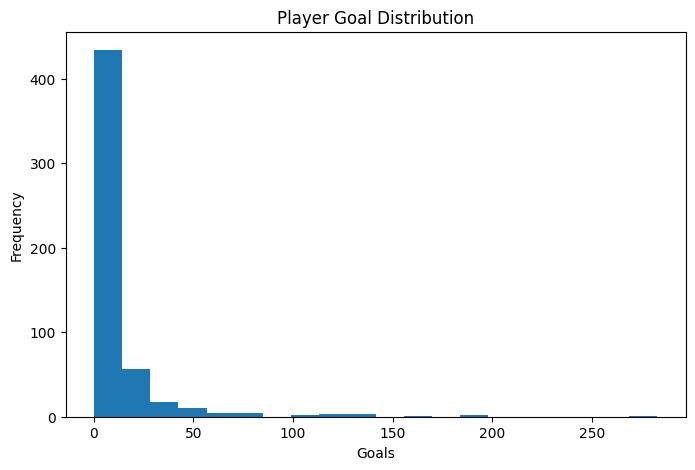

In [16]:
# =============================================================================
# GOALS DISTRIBUTION
# =============================================================================

player_goals = (

    players.groupby('user_id')['goal']
    .sum()
)

plt.figure(figsize=(8,5))

plt.hist(
    player_goals,
    bins=20
)

plt.title("Player Goal Distribution")

plt.xlabel("Goals")
plt.ylabel("Frequency")

plt.show()

In [17]:
# =============================================================================
# ASSIST ANALYSIS
# =============================================================================

players['assist'] = np.where(
    players['assist_player_id'].notnull(),
    1,
    0
)

print("\nTOTAL ASSISTS:")
print(players['assist'].sum())


TOTAL ASSISTS:
1204


In [18]:
# =============================================================================
# FOUL ANALYSIS
# =============================================================================

players['foul'] = np.where(
    players['type'] == 'FOULS',
    1,
    0
)

print("\nTOTAL FOULS:")
print(players['foul'].sum())


TOTAL FOULS:
6977



AGE SUMMARY


count    14424.000000
mean        40.035913
std        167.245166
min       -520.687201
25%         22.115674
50%         26.119097
75%         30.029432
max       2020.750171
Name: age, dtype: float64

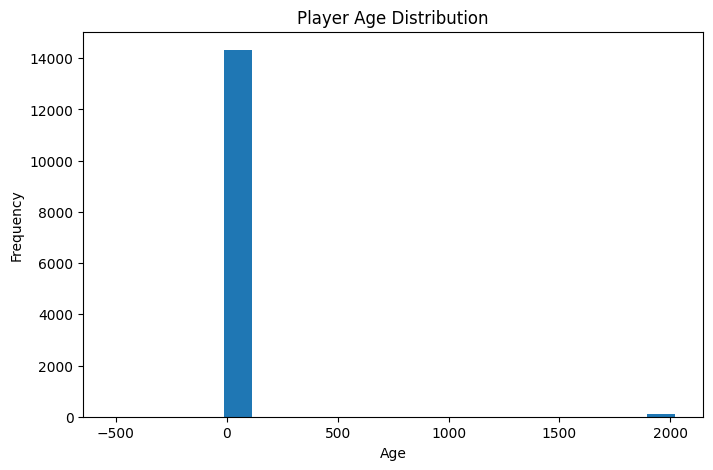

In [19]:
# =============================================================================
# AGE ANALYSIS
# =============================================================================

if 'date_of_birth' in players.columns:

    players['date_of_birth'] = pd.to_datetime(
        players['date_of_birth'],
        errors='coerce'
    )

    players['created_on'] = pd.to_datetime(
        players['created_on'],
        errors='coerce'
    )

    players['age'] = (

        (
            players['created_on']
            -
            players['date_of_birth']
        )

        .dt.days / 365.25
    )

    print("\nAGE SUMMARY")

    display(
        players['age'].describe()
    )

    plt.figure(figsize=(8,5))

    plt.hist(
        players['age'].dropna(),
        bins=20
    )

    plt.title("Player Age Distribution")

    plt.xlabel("Age")

    plt.ylabel("Frequency")

    plt.show()

In [20]:
# =============================================================================
# TEMPORAL COVERAGE
# =============================================================================

players['created_on'] = pd.to_datetime(
    players['created_on'],
    errors='coerce'
)

print("\nDATE RANGE")

print(
    players['created_on'].min(),
    " → ",
    players['created_on'].max()
)


DATE RANGE
2021-04-23 14:25:49  →  2026-06-07 16:07:20


In [21]:
# =============================================================================
# PLAYER ACTIVITY DISTRIBUTION
# =============================================================================

matches_per_player = (

    players.groupby('user_id')['match_id']
    .nunique()
)

print("\nMATCHES PER PLAYER")

display(
    matches_per_player.describe()
)


MATCHES PER PLAYER


count    538.00000
mean      12.95539
std       20.74618
min        1.00000
25%        2.00000
50%        5.00000
75%       14.00000
max      142.00000
Name: match_id, dtype: float64

In [22]:
# =============================================================================
# LOW DATA PLAYERS
# =============================================================================

low_data_players = (
    matches_per_player < 3
).sum()

print("\nPLAYERS WITH <3 MATCHES:")
print(low_data_players)



PLAYERS WITH <3 MATCHES:
189


### Feature Engineering

In [23]:
import pandas as pd
import numpy as np

players['created_on'] = pd.to_datetime(
    players['created_on'],
    errors='coerce'
)

matches['startDate'] = pd.to_datetime(
    matches['startDate'],
    errors='coerce'
)

# =====================================================
# GOALS
# =====================================================

goals_df = (
    players[players['type'] == 'SCORE']
    .groupby(['match_id','user_id'])
    .size()
    .reset_index(name='goals')
)

# =====================================================
# FOULS
# =====================================================

fouls_df = (
    players[players['type'] == 'FOULS']
    .groupby(['match_id','user_id'])
    .size()
    .reset_index(name='fouls')
)

# =====================================================
# YELLOW CARDS
# =====================================================

yellow_df = (
    players[players['type'] == 'YELLOWCARD']
    .groupby(['match_id','user_id'])
    .size()
    .reset_index(name='yellow_cards')
)

# =====================================================
# RED CARDS
# =====================================================

red_df = (
    players[players['type'] == 'REDCARD']
    .groupby(['match_id','user_id'])
    .size()
    .reset_index(name='red_cards')
)

In [24]:
assist_df = (
    players[
        players['assist_player_id'].notna()
    ]
    .groupby(
        ['match_id','assist_player_id']
    )
    .size()
    .reset_index(name='assists')
)

assist_df.rename(
    columns={
        'assist_player_id':'user_id'
    },
    inplace=True
)

In [25]:
player_match = pd.concat([

    goals_df[['match_id','user_id']],
    fouls_df[['match_id','user_id']],
    yellow_df[['match_id','user_id']],
    red_df[['match_id','user_id']],
    assist_df[['match_id','user_id']]

]).drop_duplicates()

In [26]:
dfs = [
    goals_df,
    fouls_df,
    yellow_df,
    red_df,
    assist_df
]

for df in dfs:

    player_match = player_match.merge(
        df,
        on=['match_id','user_id'],
        how='left'
    )

player_match.fillna(0, inplace=True)

,match_id,user_id,goals,fouls,yellow_cards,red_cards,assists
0,41517,435.0,1.0,0.0,0.0,0.0,0.0
1,41517,514.0,3.0,3.0,0.0,0.0,0.0
2,41517,722.0,1.0,1.0,0.0,0.0,0.0
3,41517,1719.0,1.0,0.0,0.0,0.0,0.0
4,41518,429.0,5.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...
7083,250498,0.0,0.0,0.0,0.0,0.0,8.0
7084,250498,36039.0,0.0,0.0,0.0,0.0,3.0
7085,250499,0.0,0.0,0.0,0.0,0.0,20.0
7086,250499,473.0,0.0,0.0,0.0,0.0,1.0


In [27]:
player_info = (
    players[
        [
            'match_id',
            'user_id',
            'team_id',
            'first_name',
            'last_name',
            'date_of_birth'
        ]
    ]

    .drop_duplicates(
        ['match_id','user_id']
    )
)

player_match = player_match.merge(
    player_info,
    on=['match_id','user_id'],
    how='left'
)

In [28]:
match_cols = [

    'id',

    'startDate',

    'homeTeamId',
    'awayTeamId',

    'homeTeamName',
    'awayTeamName',

    'competitionName',
    'seasonName'
]

player_match = player_match.merge(

    matches[match_cols],

    left_on='match_id',
    right_on='id',

    how='left'
)

player_match.drop(
    columns=['id'],
    inplace=True
)

player_match.rename(
    columns={'startDate':'match_date'},
    inplace=True
)

In [29]:
player_match['player_name'] = (

    player_match['first_name'].fillna('')

    + ' '

    +

    player_match['last_name'].fillna('')
)

player_match['match_date'] = pd.to_datetime(
    player_match['match_date']
)

player_match['date_of_birth'] = pd.to_datetime(
    player_match['date_of_birth'],
    errors='coerce'
)

player_match['age'] = (

    (
        player_match['match_date']
        -
        player_match['date_of_birth']
    ).dt.days

) / 365.25

In [30]:
player_match = player_match.sort_values(
    ['user_id','match_date']
)

In [31]:
player_match['goal_contribution'] = (

    player_match['goals']
    +
    player_match['assists']
)

player_match['clutch_goals'] = (
    player_match['goals'] >= 2
).astype(int)

player_match['perf_score'] = (

    player_match['goals'] * 3

    + player_match['assists'] * 2

    + player_match['clutch_goals'] * 1.5

    - player_match['fouls'] * 0.5

    - player_match['yellow_cards']

    - player_match['red_cards'] * 3
)

In [32]:
player_match['career_matches'] = (
    player_match.groupby('user_id')
    .cumcount()
)

player_match['career_goals'] = (
    player_match.groupby('user_id')['goals']
    .cumsum()
    -
    player_match['goals']
)

player_match['career_assists'] = (
    player_match.groupby('user_id')['assists']
    .cumsum()
    -
    player_match['assists']
)

player_match['career_perf_score'] = (
    player_match.groupby('user_id')['perf_score']
    .cumsum()
    -
    player_match['perf_score']
)

In [33]:
player_match['career_gpg'] = (

    player_match['career_goals']

    /

    player_match['career_matches']
    .replace(0,np.nan)
)

player_match['career_apg'] = (

    player_match['career_assists']

    /

    player_match['career_matches']
    .replace(0,np.nan)
)

player_match['career_avg_perf'] = (

    player_match['career_perf_score']

    /

    player_match['career_matches']
    .replace(0,np.nan)
)

In [34]:
for w in [3,5,10]:

    player_match[f'roll{w}_goals'] = (
        player_match.groupby('user_id')['goals']
        .transform(
            lambda x:
            x.shift(1)
            .rolling(w,min_periods=1)
            .mean()
        )
    )

    player_match[f'roll{w}_assists'] = (
        player_match.groupby('user_id')['assists']
        .transform(
            lambda x:
            x.shift(1)
            .rolling(w,min_periods=1)
            .mean()
        )
    )

    player_match[f'roll{w}_perf_score'] = (
        player_match.groupby('user_id')['perf_score']
        .transform(
            lambda x:
            x.shift(1)
            .rolling(w,min_periods=1)
            .mean()
        )
    )

In [35]:
player_match['ewm_goals'] = (
    player_match.groupby('user_id')['goals']
    .transform(
        lambda x:
        x.shift(1)
        .ewm(span=5)
        .mean()
    )
)

player_match['ewm_assists'] = (
    player_match.groupby('user_id')['assists']
    .transform(
        lambda x:
        x.shift(1)
        .ewm(span=5)
        .mean()
    )
)

player_match['ewm_perf_score'] = (
    player_match.groupby('user_id')['perf_score']
    .transform(
        lambda x:
        x.shift(1)
        .ewm(span=5)
        .mean()
    )
)

In [36]:
player_match['goal_trend'] = (
    player_match['roll5_goals']
    -
    player_match['career_gpg']
)

player_match['assist_trend'] = (
    player_match['roll5_assists']
    -
    player_match['career_apg']
)

player_match['perf_trend'] = (
    player_match['roll5_perf_score']
    -
    player_match['career_avg_perf']
)

player_match['prev_match_date'] = (
    player_match.groupby('user_id')
    ['match_date']
    .shift(1)
)

player_match['days_since_last_match'] = (
    player_match['match_date']
    -
    player_match['prev_match_date']
).dt.days

player_match['days_since_last_match'] = (
    player_match['days_since_last_match']
    .fillna(-1)
)

player_match['experience_score'] = (

    np.log1p(
        player_match['career_matches']
    )

    *

    np.log1p(
        player_match['career_goals'] + 1
    )
)

In [37]:
player_match['age'] = player_match['age'].fillna(
    player_match['age'].median()
)

In [38]:
player_match['log_career_goals'] = np.log1p(
    player_match['career_goals']
)

player_match['log_career_assists'] = np.log1p(
    player_match['career_assists']
)

player_match['log_career_matches'] = np.log1p(
    player_match['career_matches']
)

# Numeric columns
num_cols = player_match.select_dtypes(
    include=np.number
).columns

player_match[num_cols] = (
    player_match[num_cols]
    .fillna(0)
)

player_match['best_match_score'] = (
    player_match.groupby('match_id')['perf_score']
    .transform('max')
)

player_match['is_best_player'] = (
    player_match['perf_score']
    ==
    player_match['best_match_score']
).astype(int)



In [39]:
# save filtered data in temp variable
temp = player_match[player_match['team_id'] != 0].copy()

# now remove those rows from original dataframe
player_match = player_match.drop(player_match[player_match['team_id'] == 0].index)

In [40]:
player_match.to_csv(
    "Futsal_match_ml.csv",
    index=False
)

print(player_match.shape)
player_match.head()

(6970, 53)


,match_id,user_id,goals,fouls,yellow_cards,red_cards,assists,team_id,first_name,last_name,...,assist_trend,perf_trend,prev_match_date,days_since_last_match,experience_score,log_career_goals,log_career_assists,log_career_matches,best_match_score,is_best_player
751,55814,382.0,1.0,0.0,0.0,0.0,0.0,22.0,Ernie,Simsek,...,0.0,0.0,NaT,-1.0,0.000000,0.000000,0.0,0.000000,3.0,1
874,55835,382.0,1.0,1.0,0.0,0.0,0.0,22.0,Ernie,Simsek,...,0.0,0.0,2022-05-13,35.0,0.761500,0.693147,0.0,0.693147,9.0,0
926,55844,382.0,1.0,0.0,0.0,0.0,0.0,22.0,Ernie,Simsek,...,0.0,0.0,2022-06-17,7.0,1.523000,1.098612,0.0,1.098612,3.0,1
4479,72957,382.0,0.0,2.0,0.0,0.0,0.0,22.0,Ernie,Simsek,...,0.0,0.0,2022-06-24,21.0,2.231155,1.386294,0.0,1.386294,7.5,0
4493,72961,382.0,0.0,2.0,0.0,0.0,0.0,22.0,Ernie,Simsek,...,0.0,0.0,2022-07-15,7.0,2.590290,1.386294,0.0,1.609438,3.0,0


In [41]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

In [42]:
df = pd.read_csv(
    "Futsal_match_ml.csv"
)

print(df.shape)
df.head()

(6970, 53)


,match_id,user_id,goals,fouls,yellow_cards,red_cards,assists,team_id,first_name,last_name,...,assist_trend,perf_trend,prev_match_date,days_since_last_match,experience_score,log_career_goals,log_career_assists,log_career_matches,best_match_score,is_best_player
0,55814,382.0,1.0,0.0,0.0,0.0,0.0,22.0,Ernie,Simsek,...,0.0,0.0,NaN,-1.0,0.000000,0.000000,0.0,0.000000,3.0,1
1,55835,382.0,1.0,1.0,0.0,0.0,0.0,22.0,Ernie,Simsek,...,0.0,0.0,2022-05-13,35.0,0.761500,0.693147,0.0,0.693147,9.0,0
2,55844,382.0,1.0,0.0,0.0,0.0,0.0,22.0,Ernie,Simsek,...,0.0,0.0,2022-06-17,7.0,1.523000,1.098612,0.0,1.098612,3.0,1
3,72957,382.0,0.0,2.0,0.0,0.0,0.0,22.0,Ernie,Simsek,...,0.0,0.0,2022-06-24,21.0,2.231155,1.386294,0.0,1.386294,7.5,0
4,72961,382.0,0.0,2.0,0.0,0.0,0.0,22.0,Ernie,Simsek,...,0.0,0.0,2022-07-15,7.0,2.590290,1.386294,0.0,1.609438,3.0,0


In [43]:
DROP_COLS = [

    'match_id',
    'user_id',

    'player_name',
    'first_name',
    'last_name',

    'date_of_birth',
    'match_date',
    'prev_match_date',

    'goals',
    'assists',
    'fouls',
    'yellow_cards',
    'red_cards',

    'goal_contribution',
    'clutch_goals',
    'perf_score',
    'homeTeamName',
    'awayTeamName',
    'competitionName',
    'seasonName',

    'best_match_score',

    'is_best_player'
]

X = df.drop(
    columns=DROP_COLS,
    errors='ignore'
)

y = df['is_best_player']

print(X)

      team_id  homeTeamId  awayTeamId        age  career_matches  \
0        22.0          22         322  37.368925               0   
1        22.0          22          21  37.464750               1   
2        22.0         322          22  37.483915               2   
3        22.0          21          22  37.541410               3   
4        22.0          22          18  37.560575               4   
...       ...         ...         ...        ...             ...   
6965    344.0          16         344  28.832307               1   
6966     16.0         344          16  35.794661               0   
6967     16.0          18          16  35.813826               1   
6968    329.0         329          17  20.271047               0   
6969     17.0          17         344  25.648186               0   

      career_goals  career_assists  career_perf_score  career_gpg  career_apg  \
0              0.0             0.0                0.0        0.00         0.0   
1              1.0   

In [44]:
feature_names = X.columns.tolist()

joblib.dump(
    feature_names,
    "feature_names.pkl"
)

print(
    f"Saved {len(feature_names)} features"
)

Saved 31 features


In [45]:
X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    stratify=y,

    random_state=42
)

In [46]:
MODELS = {

    "XGBoost": XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        scale_pos_weight=7.5,
        random_state=42
    ),

    "LightGBM": LGBMClassifier(
        class_weight='balanced',
        random_state=42
    ),

    "CatBoost": CatBoostClassifier(
        auto_class_weights='Balanced',
        verbose=0,
        random_state=42
    )
}

In [47]:
PARAMS = {

    "XGBoost": {

        'n_estimators':[100,200],

        'max_depth':[3,5,7],

        'learning_rate':[0.01,0.05,0.1]
    },

    "LightGBM": {

        'n_estimators':[100,200],

        'max_depth':[3,5,7],

        'learning_rate':[0.01,0.05,0.1]
    },

    "CatBoost": {

        'depth':[4,6,8],

        'learning_rate':[0.01,0.05,0.1],

        'iterations':[200,500]
    }
}

In [48]:
def evaluate_model(
    model,
    X_test,
    y_test
):

    preds = model.predict(
        X_test
    )

    probs = model.predict_proba(
        X_test
    )[:,1]

    results = {

        "Accuracy":
        accuracy_score(
            y_test,
            preds
        ),

        "Precision":
        precision_score(
            y_test,
            preds
        ),

        "Recall":
        recall_score(
            y_test,
            preds
        ),

        "F1":
        f1_score(
            y_test,
            preds
        ),

        "ROC_AUC":
        roc_auc_score(
            y_test,
            probs
        )
    }

    return results

In [49]:
def train_model(

    model_name,
    model,

    param_grid,

    X_train,
    y_train
):

    print(
        f"\nTraining {model_name}"
    )

    grid = GridSearchCV(

        estimator=model,

        param_grid=param_grid,

        scoring='f1',

        cv=5,

        n_jobs=-1,

        verbose=2
    )

    grid.fit(
        X_train,
        y_train
    )

    print(
        f"Best Score: {grid.best_score_}"
    )

    print(
        f"Best Params: {grid.best_params_}"
    )

    return grid

In [50]:
all_results = []

trained_models = {}

for model_name in MODELS:

    grid = train_model(

        model_name,

        MODELS[model_name],

        PARAMS[model_name],

        X_train,
        y_train
    )

    trained_models[model_name] = grid

    metrics = evaluate_model(

        grid.best_estimator_,

        X_test,
        y_test
    )

    metrics['Model'] = model_name

    metrics['CV_F1'] = (
        grid.best_score_
    )

    all_results.append(
        metrics
    )


Training XGBoost
Fitting 5 folds for each of 18 candidates, totalling 90 fits


Best Score: 0.30745376970931915
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}

Training LightGBM
Fitting 5 folds for each of 18 candidates, totalling 90 fits
[LightGBM] [Info] Number of positive: 655, number of negative: 4921
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000271 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4048
[LightGBM] [Info] Number of data points in the train set: 5576, number of used features: 31
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further spl

In [51]:
results_df = pd.DataFrame(
    all_results
)

results_df = results_df.sort_values(
    'CV_F1',
    ascending=False
)

display(results_df)

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,CV_F1
0,0.695839,0.225738,0.652439,0.335423,0.724276,XGBoost,0.307454
2,0.732425,0.239401,0.585366,0.339823,0.724137,CatBoost,0.307152
1,0.701578,0.230769,0.658537,0.341772,0.719485,LightGBM,0.306399


In [ ]:
# for model_name, grid in trained_models.items():

#     filename = (
#         model_name
#         .lower()
#         .replace(" ","_")
#         + ".pkl"
#     )

#     joblib.dump(
#         grid.best_estimator_,
#         filename
#     )

#     print(
#         f"Saved {filename}"
#     )

Saved xgboost.pkl
Saved lightgbm.pkl
Saved catboost.pkl


In [ ]:
best_model_name = (
    results_df.iloc[0]['Model']
)

best_model = (

    trained_models[
        best_model_name
    ]

    .best_estimator_
)

joblib.dump(

    best_model,

    f"{best_model_name}_players_model.pkl"
)

print(
    f"Best Model: {best_model_name}"
)

print(
    "Saved as best_player_model.pkl"
)

Best Model: XGBoost
Saved as best_player_model.pkl


In [ ]:
# results_df.to_csv(
#     "model_comparison.csv",
#     index=False
# )

# results_df

,Accuracy,Precision,Recall,F1,ROC_AUC,Model,CV_F1
0,0.695839,0.225738,0.652439,0.335423,0.724276,XGBoost,0.307454
2,0.732425,0.239401,0.585366,0.339823,0.724137,CatBoost,0.307152
1,0.701578,0.230769,0.658537,0.341772,0.719485,LightGBM,0.306399


In [57]:
import pandas as pd
import numpy as np
import joblib

# ============================================================
# LOAD FILES
# ============================================================

BEST_PLAYER_MODEL = joblib.load("best_player_model.pkl")
FEATURE_COLUMNS = joblib.load("feature_names.pkl")

player_df = pd.read_csv("Futsal_match_ml.csv")

# ============================================================
# INFERENCE FUNCTION
# ============================================================

def predict_best_player(match_prediction_json):

    home_id = match_prediction_json["homeID"]
    away_id = match_prediction_json["awayID"]

    predicted_winner_name = match_prediction_json["prediction"]

    # --------------------------------------------------------
    # GET TEAM NAME MAPPING
    # --------------------------------------------------------

    team_mapping = (
        player_df[
            ["team_id"]
        ]
        .drop_duplicates()
    )

    # --------------------------------------------------------
    # FIND WINNING TEAM ID
    # --------------------------------------------------------

    latest_rows = player_df.sort_values(
        "match_date"
    )

    home_team_name = (
        latest_rows[
            latest_rows["homeTeamId"] == home_id
        ]["homeTeamName"]
        .dropna()
        .iloc[-1]
    )

    away_team_name = (
        latest_rows[
            latest_rows["awayTeamId"] == away_id
        ]["awayTeamName"]
        .dropna()
        .iloc[-1]
    )

    if predicted_winner_name == home_team_name:
        winning_team_id = home_id
    else:
        winning_team_id = away_id

    # --------------------------------------------------------
    # LATEST PLAYER FEATURES
    # --------------------------------------------------------

    latest_player_features = (
        player_df
        .sort_values("match_date")
        .groupby("user_id")
        .tail(1)
    )

    winning_players = latest_player_features[
        latest_player_features["team_id"] == winning_team_id
    ].copy()

    if len(winning_players) == 0:
        return {
            "error": "No player data found"
        }

    # --------------------------------------------------------
    # MODEL PREDICTION
    # --------------------------------------------------------

    X_players = winning_players[
        FEATURE_COLUMNS
    ]

    winning_players["best_player_probability"] = (
        BEST_PLAYER_MODEL.predict_proba(X_players)[:,1]
    )

    winning_players = winning_players.sort_values(
        "best_player_probability",
        ascending=False
    )

    # --------------------------------------------------------
    # BEST PLAYER
    # --------------------------------------------------------

    best_player_name = (
        winning_players.iloc[0]["player_name"]
    )

    # --------------------------------------------------------
    # PLAYER LIST
    # --------------------------------------------------------

    player_predictions = []

    for _, row in winning_players.iterrows():

        player_predictions.append({
            "playerName": row["player_name"],
            "playerID": int(row["user_id"]),
            "probability": round(
                float(
                    row["best_player_probability"]
                ) * 100,
                2
            )
        })

    # --------------------------------------------------------
    # FINAL OUTPUT
    # --------------------------------------------------------

    result = {
        "homeTeam": home_team_name,
        "awayTeam": away_team_name,
        "homeWinProbability": round(
            match_prediction_json["confidence"],
            2
        ),
        "awayWinProbability": round(
            100 - match_prediction_json["confidence"],
            2
        ),
        "predictedWinner": predicted_winner_name,
        "predictedBestPlayer": best_player_name,
        "winningTeamPlayers": player_predictions[:5]
    }

    return result


# ============================================================
# SAMPLE INPUT
# ============================================================

match_input = {
    "homeID": 331,
    "awayID": 344,
    "prediction": "Hume FC",
    "confidence": 89.49
}

result = predict_best_player(match_input)

print(result)

{'homeTeam': 'Hume FC', 'awayTeam': 'Thornbury Utd FC ', 'homeWinProbability': 89.49, 'awayWinProbability': 10.51, 'predictedWinner': 'Hume FC', 'predictedBestPlayer': 'Jamie Dib', 'winningTeamPlayers': [{'playerName': 'Jamie Dib', 'playerID': 32082, 'probability': 65.71}, {'playerName': 'Kenta Sasaki', 'playerID': 23112, 'probability': 57.95}, {'playerName': 'Anthony Haddad', 'playerID': 32063, 'probability': 53.23}, {'playerName': 'Nejdet Sahin', 'playerID': 1018, 'probability': 47.85}, {'playerName': 'Khaled Atik', 'playerID': 587, 'probability': 43.91}]}


In [58]:
import pandas as pd

importance = pd.DataFrame({
    "feature": FEATURE_COLUMNS,
    "importance": best_model.feature_importances_
})

importance.sort_values(
    "importance",
    ascending=False
).head(20)

,feature,importance
10,career_avg_perf,0.274541
17,roll10_goals,0.088871
8,career_gpg,0.071568
6,career_assists,0.062294
19,roll10_perf_score,0.041824
1,homeTeamId,0.038008
11,roll3_goals,0.036881
0,team_id,0.033864
5,career_goals,0.032824
22,ewm_perf_score,0.032801
